# How to read EnergiBridge Data

This Notebook contains a basic reference to the fields outputed by EnergiBridge.

EnnergiBridge is simply a wrapper to facilitate access to the Model-Specific Registers (MSR) that report energy consumption, and power usage information from NVIDIA libraries. Therefore, the output fields will depend on what information the CPU models provide.

I ran EnergiBridge for different CPUs and GPUs that I have access to. The following tables show the output fields for these architectures. These outputs should be consistent for different CPUs of the same vendor, but there might be some differences between models. For example, the 7900x does not have integrated graphics, while AMD laptop CPUs do, which might add additional fields. Double-check the CSV output when running Energibridge for the first time.

## EnergiBridge fields for AMD (Ryzen 7900X)

|        Label        | Meaning                                                                              |
|:-------------------:|--------------------------------------------------------------------------------------|
| Delta               | Difference in ms with respect to the previous data point                             |
| Time                | Unix timestamp in ms                                                                 |
| CPU_ENERGY (J)      | Monotonic counter of total CPU Energy usage                                          |
| COREX_ENERGY (J)    | Monotonic counter of total energy used by core X                                     |
| COREX_FREQ (MHZ)    | Frequency of core X                                                                  |
| COREX_PSTATE        | PSTATE of core X. See [these docs](https://docs.kernel.org/admin-guide/pm/amd-pstate.html)                                                                  |
| CORE0_VOLT (V)      | Voltage of core X                                                                    |
| CPU_USAGE_X         | Usage percentage of logical core X                                                   |
| TOTAL_MEMORY        | Total memory for the system (bytes)                                                  |
| USED_MEMORY         | Memory in use                                                                        |
| TOTAL_SWAP          | Total swap size                                                                      |
| USED_SWAP           | Swap in use                                                                          |

## EnergiBridge fields for Intel (i7-8750H)

|        Label        | Meaning                                                                              |
|:-------------------:|--------------------------------------------------------------------------------------|
| Delta               | Difference in ms with respect to the previous data point                             |
| Time                | Unix timestamp in ms                                                                 |
| CPU_FREQUENCY_X     | Frequency of core X                                                                  |
| CPU_USAGE_X         | Usage percentage of core X                                                           |
| DRAM_ENERGY (J)     | Monotonic counter of total energy used by RAM                                        |
| PACKAGE_ENERGY (J)  | Monotonic counter of total energy used by complete CPU + integrated graphics package |
| PP0_ENERGY (J)      | Monotonic counter of total energy used by entire CPU                                 |
| PP1_ENERGY (J)      | Monotonic counter of total energy used by integrated graphics                        |
| TOTAL_MEMORY        | Total memory for the system (bytes)                                                  |
| USED_MEMORY         | Memory in use                                                                        |
| TOTAL_SWAP          | Total swap size                                                                      |
| USED_SWAP           | Swap in use                                                                          |


## EnergiBridge fields for Apple M1
|        Label        | Meaning                                                                              |
|:-------------------:|--------------------------------------------------------------------------------------|
| Delta               | Difference in ms with respect to the previous data point                             |
| Time                | Unix timestamp in ms                                                                 |
| CPU_FREQUENCY_X     | Frequency of core X                                                                  |
| CPU_USAGE_X         | Usage percentage of core X                                                           |
| CPU_TEMP_X          | Core Temperature at the timestamp                                                    |
| SYSTEM_POWER (Watts)| Monotonic counter of total energy used by integrated graphics                        |
| TOTAL_MEMORY        | Total memory for the system (bytes)                                                  |
| USED_MEMORY         | Memory in use                                                                        |
| TOTAL_SWAP          | Total swap size                                                                      |
| USED_SWAP           | Swap in use                                                                          |

## Nvidia GPU output fields (GTX 1060)

|        Label        | Meaning                                                                              |
|:-------------------:|--------------------------------------------------------------------------------------|
| GPU0_POWER (mWatts) | GPU power at the given timestamp                                                     |
| GPU0_TEMPERATURE    | GPU temperature (Celsius)                                                            |
| GPU0_USAGE          | GPU usage percentage                                                                 |
| GPU0_MEMORY_TOTAL   | Total GPU memory (MB)                                                                |
| GPU0_MEMORY_USED    | Used GPU memory (MB)                                                                 |

## Basic EnergiBridge data reading

This notebook includes a couple of examples on how to read energy data from a EnergiBridge CSV. Examples are ran on an AMD CPU.

### Energy usage of Redis Benchmark

The files in `data/redis` contain measurements for a run of the Redis benchmark in an AMD CPU. There are 2 measurements: one for Redis running in a Ubuntu docker container and another using an Alpine container. We want to compare energy usage for different Docker base images. This is based on [this paper](https://arxiv.org/abs/2412.10063).

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_alpine = pd.read_csv("runner/results/experiment-20260604-160438/config-01__alpine/run-001.csv")
df_ubuntu = pd.read_csv("runner/results/experiment-20260604-160438/config-02__ubuntu/run-001.csv")

In [4]:
# AMD reports energy as a monotonic counter for individual cores and whole cpu, rather than system power

energy_alpine = df_alpine['CORE0_ENERGY (J)'].iloc[-1] - df_alpine['CORE0_ENERGY (J)'].iloc[0]
print('Total energy for Alpine: {} J'.format(energy_alpine))
energy_ubuntu = df_ubuntu['CORE0_ENERGY (J)'].iloc[-1] - df_ubuntu['CORE0_ENERGY (J)'].iloc[0]
print('Total energy for Ubuntu: {} J'.format(energy_ubuntu))

Total energy for Alpine: 1744.9081268310547 J
Total energy for Ubuntu: 1571.989028930664 J


In [5]:
# AMD reports energy as a monotonic counter for individual cores and whole cpu, rather than system power

energy_alpine = df_alpine['CPU_ENERGY (J)'].iloc[-1] - df_alpine['CPU_ENERGY (J)'].iloc[0]
print('Total energy for Alpine: {} J'.format(energy_alpine))
energy_ubuntu = df_ubuntu['CPU_ENERGY (J)'].iloc[-1] - df_ubuntu['CPU_ENERGY (J)'].iloc[0]
print('Total energy for Ubuntu: {} J'.format(energy_ubuntu))

Total energy for Alpine: 15207.51480102539 J
Total energy for Ubuntu: 14779.013000488281 J


### Compute CPU Power and plot power usage across time

Recreate the plot from the first example, showing power usage across the execution. In this case, since AMD reports energy instead of power, you need to compute instant power between datapoints, based on the difference in energy and time.

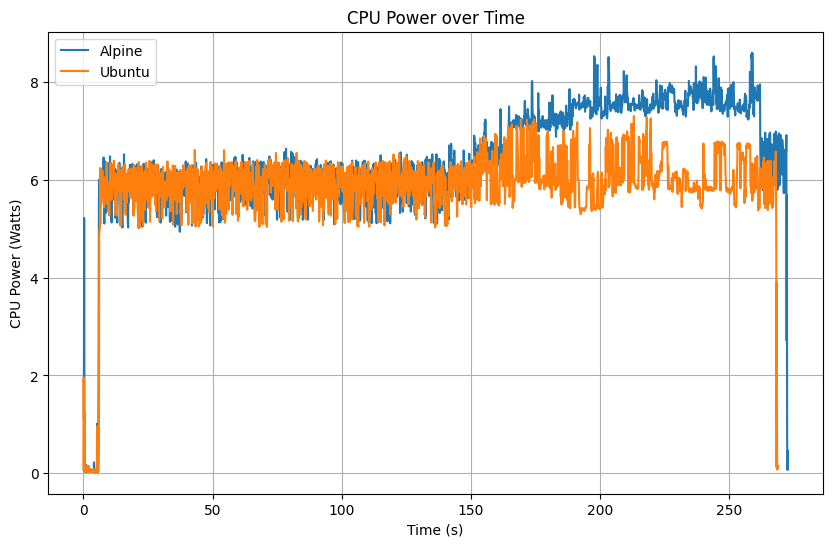

In [6]:
#key = 'CPU_ENERGY (J)'
key = 'CORE0_ENERGY (J)'

# Add column for power in Watts by taking the difference of energy and dividing by the difference in time (convert to seconds)
df_alpine['CPU_POWER (W)'] = df_alpine[key].diff() / df_alpine['Time'].diff() * 1000
df_ubuntu['CPU_POWER (W)'] = df_ubuntu[key].diff() / df_ubuntu['Time'].diff() * 1000

# Reset time to start at 0
df_alpine['Time'] = df_alpine['Time'] - df_alpine['Time'].iloc[0]
df_ubuntu['Time'] = df_ubuntu['Time'] - df_ubuntu['Time'].iloc[0]
# Plot power
plt.figure(figsize=(10, 6))
plt.plot(df_alpine['Time']/1000, df_alpine['CPU_POWER (W)'], label='Alpine')
plt.plot(df_ubuntu['Time']/1000, df_ubuntu['CPU_POWER (W)'], label='Ubuntu')
plt.xlabel('Time (s)')
plt.ylabel('CPU Power (Watts)')
plt.title('CPU Power over Time')
plt.legend()
plt.grid()
plt.show()

In [7]:
experiment = "experiment-20260604-160438"

key = "CORE0_ENERGY (J)"

# Aggregate all measurements for Alpine and Ubuntu from their config folders
dfs_alpine = [pd.read_csv(f"runner/results/{experiment}/config-01__alpine/run-{i:03d}.csv") for i in range(1, 31)]
dfs_ubuntu = [pd.read_csv(f"runner/results/{experiment}/config-02__ubuntu/run-{i:03d}.csv") for i in range(1, 31)]

data_alpine = {"Time (s)": [], key: []}
data_ubuntu = {"Time (s)": [], key: []}

power_alpine = pd.DataFrame()
power_ubuntu = pd.DataFrame()

i = 1

for df in dfs_alpine:
    data_alpine["Time (s)"].extend([(df['Time'].iloc[-1] - df['Time'].iloc[0]) / 1000])

    energy = df[key].iloc[-1] - df[key].iloc[0]

    if energy < 0:
        # MSR register overflow, correct by adding the max value
        energy += df[key].max()
        print(f"Overflow detected in run-{i:03d}, correcting energy by adding {df[key].max()} J")   

    data_alpine[key].extend([energy])

    # Get times array starting from 0
    times = (df['Time'] - df['Time'].iloc[0]) / 1000
    times = times.values[2:]

    # Compute instantaneous power and plot. Fix overflow by adding max value when power is negative
    df['CPU_POWER (W)'] = df[key].diff() / df['Time'].diff() * 1000
    df['CPU_POWER (W)'] = df['CPU_POWER (W)'].apply(lambda x: x if x >= 0 else x + df['CPU_POWER (W)'].max())

    # Create a dataframe with time and power for this run and append to list of dataframes for Alpine
    df_power_alpine = pd.DataFrame({'Time (s)': times, 'CPU_POWER (W)': df['CPU_POWER (W)'].values[2:]})
    
    df_power_alpine['Index'] = range(len(df_power_alpine))
    power_alpine = pd.concat([power_alpine, df_power_alpine], ignore_index=True)

    i += 1

i = 1

for df in dfs_ubuntu:    
    data_ubuntu["Time (s)"].extend([(df['Time'].iloc[-1] - df['Time'].iloc[0]) / 1000])
    energy = df[key].iloc[-1] - df[key].iloc[0]

    if energy < 0:
        # MSR register overflow, correct by adding the max value
        energy += df[key].max()
        print(f"Overflow detected in run-{i:03d}, correcting energy by adding {df[key].max()} J")   
    data_ubuntu[key].extend([energy])

    # Get times array starting from 0
    times = (df['Time'] - df['Time'].iloc[0]) / 1000
    times = times.values[2:]

    # Compute instantaneous power and plot. Fix overflow by adding max value when power is negative
    df['CPU_POWER (W)'] = df[key].diff() / df['Time'].diff() * 1000
    df['CPU_POWER (W)'] = df['CPU_POWER (W)'].apply(lambda x: x if x >= 0 else x + df['CPU_POWER (W)'].max())

    # Create a dataframe with time and power for this run and append to list of dataframes for Ubuntu
    df_power_ubuntu = pd.DataFrame({'Time (s)': times, 'CPU_POWER (W)': df['CPU_POWER (W)'].values[2:]})
    df_power_ubuntu['Index'] = range(len(df_power_ubuntu))
    power_ubuntu = pd.concat([power_ubuntu, df_power_ubuntu], ignore_index=True)

    i += 1

In [8]:
# Find outliers in data_alpine and data_ubuntu using IQR method and remove them
def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if x >= lower_bound and x <= upper_bound]

data_alpine[key] = remove_outliers(data_alpine[key])
data_ubuntu[key] = remove_outliers(data_ubuntu[key])

data_alpine["Time (s)"] = remove_outliers(data_alpine["Time (s)"])
data_ubuntu["Time (s)"] = remove_outliers(data_ubuntu["Time (s)"])

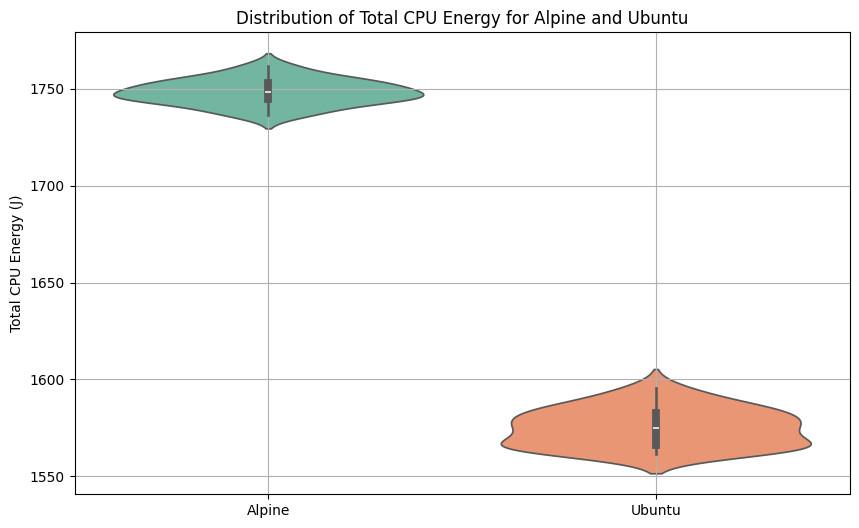

Median energy for Alpine: 1748.32 J
Median energy for Ubuntu: 1575.11 J
Percentage difference in median energy between Alpine and Ubuntu: -11.00%


In [9]:
# Violin plots
plt.figure(figsize=(10, 6))
sns.violinplot(data=[data_alpine[key], data_ubuntu[key]], palette="Set2")
plt.xticks([0, 1], ['Alpine', 'Ubuntu'])
plt.ylabel('Total CPU Energy (J)')
plt.title('Distribution of Total CPU Energy for Alpine and Ubuntu')
plt.grid()
plt.show()

# Print percentage difference in median energy between Alpine and Ubuntu
median_alpine = np.median(data_alpine[key])
median_ubuntu = np.median(data_ubuntu[key])
percent_diff = (median_ubuntu - median_alpine) / median_ubuntu * 100
print(f"Median energy for Alpine: {median_alpine:.2f} J")
print(f"Median energy for Ubuntu: {median_ubuntu:.2f} J")
print(f"Percentage difference in median energy between Alpine and Ubuntu: {percent_diff:.2f}%")

In [10]:
# Test for normality using Shapiro-Wilk test
from scipy.stats import shapiro

stat_alpine, p_alpine = shapiro(data_alpine[key])
stat_ubuntu, p_ubuntu = shapiro(data_ubuntu[key])

print(f"Shapiro-Wilk test for Alpine: statistic={stat_alpine:.4f}, p-value={p_alpine:.4f}")
print(f"Shapiro-Wilk test for Ubuntu: statistic={stat_ubuntu:.4f}, p-value={p_ubuntu:.4f}")

Shapiro-Wilk test for Alpine: statistic=0.9834, p-value=0.9220
Shapiro-Wilk test for Ubuntu: statistic=0.9435, p-value=0.1130


In [14]:
# Statistical significance using Mann-Whitney U
from scipy.stats import mannwhitneyu


stat, p_value = mannwhitneyu(data_alpine[key], data_ubuntu[key], alternative='two-sided')
print(f"Mann-Whitney U test: statistic={stat:.4f}, p-value={p_value:.4f}")

# Effect size using Vargha-Delaney A measure
def vargha_delaney_a(data1, data2):
    n1 = len(data1)
    n2 = len(data2)
    ranks = pd.Series(data1 + data2).rank()
    rank_sum1 = ranks[:n1].sum()
    a = (rank_sum1 / n1 - (n1 + 1) / 2) / n2
    return a

a = vargha_delaney_a(data_alpine[key], data_ubuntu[key])
print(f"Vargha-Delaney A measure: {a:.4f}")


Mann-Whitney U test: statistic=840.0000, p-value=0.0000
Vargha-Delaney A measure: 1.0000


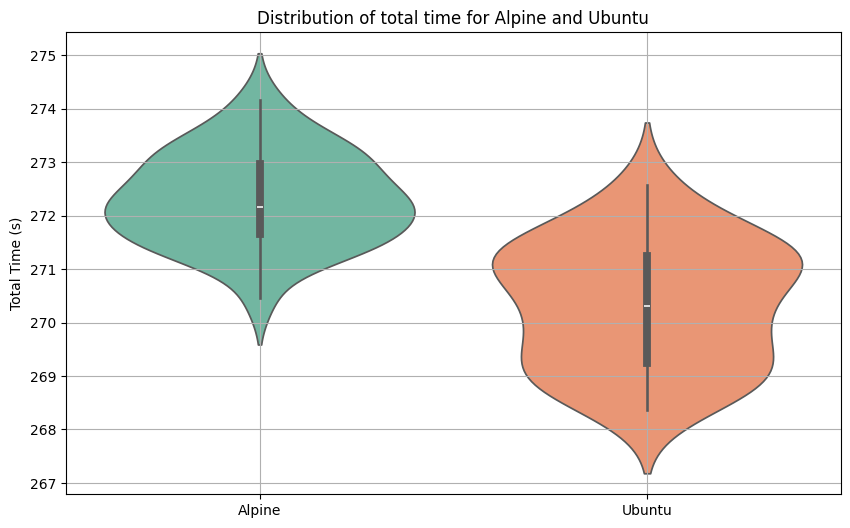

In [12]:
# Violin plots
plt.figure(figsize=(10, 6))
sns.violinplot(data=[data_alpine["Time (s)"], data_ubuntu["Time (s)"]], palette="Set2")
plt.xticks([0, 1], ['Alpine', 'Ubuntu'])
plt.ylabel('Total Time (s)')
plt.title('Distribution of total time for Alpine and Ubuntu')
plt.grid()
plt.show()

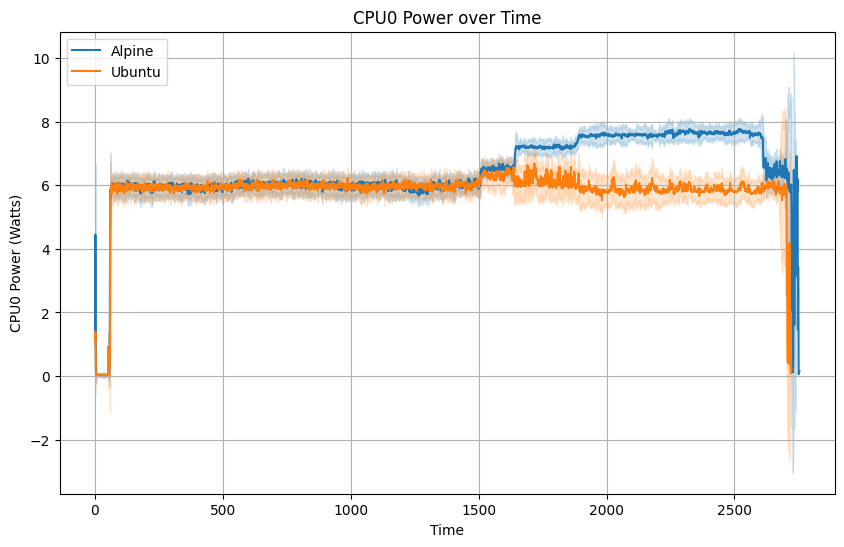

In [13]:
# Create an aggregated powerplot with the median and quartiles for each time point across all runs for Alpine and Ubuntu
plt.figure(figsize=(10, 6))
sns.lineplot(data=power_alpine, x='Index', y='CPU_POWER (W)', estimator='median', errorbar='sd', label='Alpine')
sns.lineplot(data=power_ubuntu, x='Index', y='CPU_POWER (W)', estimator='median', errorbar='sd', label='Ubuntu')
plt.xlabel('Time')
plt.ylabel('CPU0 Power (Watts)')
plt.title('CPU0 Power over Time')
plt.legend()
plt.grid()
plt.show()